In [1]:
from scipy.special import roots_jacobi, eval_jacobi
import pandas as pd
import numpy as np
import uxarray as ux
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [3]:
grid_file = ux.open_grid('TEMPEST_ne30.g')
node_connect = grid_file.face_node_connectivity

In [4]:
npts = 4
p_order = npts - 1
xinterior, w = roots_jacobi(p_order - 1,1,1) # returns interior GLL nodes from range -1 and 1
GLL_points = np.pad(xinterior, (1, 1), 'constant', constant_values=(-1, 1))

ref_coords = np.meshgrid(GLL_points, GLL_points[::-1])

### Define Derivative Operators:

In [5]:
# Assumes array_in has dims ('x2', 'y2'):
def pd_y(array_in, xr_D):
    return(xr.apply_ufunc(np.matmul,
           xr_D, array_in,
           input_core_dims=[['x2', 'y2'], ['x2', 'y2']],
           output_core_dims=[['x2', 'y2']],
           vectorize=True,
           dask="parallelized",
           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype]))

In [6]:
# Assumes array_in has dims ('n_face', 'x2', 'y2'):
def pd_x(array_in, xr_D):
    array_out = xr.apply_ufunc(np.matmul,
                   xr_D, array_in.transpose('n_face', 'y2', 'x2'),
                   input_core_dims=[['x2', 'y2'], ['y2', 'x2']],
                   output_core_dims=[['y2', 'x2']],
                   vectorize=True,
                   dask="parallelized",
                   output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Return a transposed array:
    return(array_out.transpose('n_face', 'x2', 'y2'))

In [7]:
def vandermonde(npts_values, return_type):
    # For the monomial basis: 
    if return_type == 'Monomial':
        return(np.vander(npts_values, increasing = True))
    elif return_type == 'Legendre':
        return(np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1))

In [8]:
def Ld_vandermonde(npts_values): 
    
    LP = np.polynomial.legendre
    v_matrix = np.polynomial.legendre.legvander(npts_values, len(npts_values)-1)
    d_v_matrix = np.zeros_like(v_matrix)

    for i in range(len(npts_values)):
        # Coefficients for the i-th Legendre polynomial (e.g., [0, 0, 1] for P_2)
        coeffs = np.zeros(len(npts_values))
        coeffs[i] = 1

        # Compute the derivative of the i-th Legendre polynomial
        deriv_coeffs = LP.legder(coeffs, m=1) # m=1 for first derivative

        # Evaluate the derivative at the points x
        d_v_matrix[:, i] = LP.legval(npts_values, deriv_coeffs)
        
    return(d_v_matrix)

In [9]:
def return_D(V1, V2):
    return(np.matmul(V2, np.linalg.inv(V1)))

In [10]:
V1 = vandermonde(GLL_points, 'Legendre')
V2 = Ld_vandermonde(GLL_points)
D = return_D(V1, V2)

In [11]:
xr_D = xr.DataArray(data = D, coords = {'x2' : np.arange(npts),
                                        'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

### Map GLL points to the sphere:

In [12]:
# Returns Cartesian coordinates on the unit sphere: 
# Fills in starting with C1 from the bottom left, moves counterclockwise:
# GLL_point 12 is c1, GLL_point 15 is c2, GLL_point 3 is c3, GLL_point 0 is c4

def map_cartesian(grid_file, ref_coords, GLL_points):
    
    # Define arrays for corners in x_2, y_2:
    node_connect = grid_file.face_node_connectivity
    
    # Return the x, y, z comps of element corners of faces:
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    t1 = (1 - ref_coords[0]) * (1 - ref_coords[1])
    t2 = (1 + ref_coords[0]) * (1 - ref_coords[1])
    t3 = (1 + ref_coords[0]) * (1 + ref_coords[1])
    t4 = (1 - ref_coords[0]) * (1 + ref_coords[1])
    
    r1 = ((1/4) * (np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(5400, len(GLL_points), len(GLL_points))
    
    r2 = ((1/4) * (np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(5400, len(GLL_points), len(GLL_points))
    
    r3 = ((1/4) * (np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(5400, len(GLL_points), len(GLL_points))
    
    r_vector = xr.Dataset(data_vars = {'x_comp' : (["n_face", "x2", "y2"], r1), 
                                       'y_comp' : (["n_face", "x2", "y2"], r2), 
                                       'z_comp' : (["n_face", "x2", "y2"], r3)},
                          coords = {'n_face' : (('n_face'), node_x.coords['n_face'].values),
                                    'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))})
    
    r_norm = r_vector / np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2))
    return(r_norm, np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2)))

In [13]:
# Convert Cartesian coordinates on the unit sphere to lat/lon in radians: 

def map_spherical(input_array):
    
    # Note: lon returned from [-pi, pi], lat returned from [0, pi]
    lon_array = np.arctan2(input_array['y_comp'], input_array['x_comp'])
    lat_array = np.arccos(input_array['z_comp'])
    
    # Shift lon to [0, 2pi] and lat to [pi/2, -pi/2]:
    lat_shift = -(lat_array - (np.pi / 2))
    lon_shift = np.where(lon_array < 0, lon_array + (2 * np.pi), lon_array)
    
    return(xr.Dataset(data_vars = {'lat' : (["n_face", "x2", "y2"], lat_shift.data), 
                                   'lon' : (["n_face", "x2", "y2"], lon_shift.data)},
                      coords = {'n_face' : (('n_face'), input_array.coords['n_face'].values), 
                                'GLL_points' : (('x2', 'y2'), input_array.coords['GLL_points'].values)}))

### Determine neighbors for DSS:

In [14]:
# Insert 2 additional data_vars, one for shared edges and one for shared corners:

def return_neighbors(grid_array, value_array, npts):
    # Preallocate arrays for corners and edges:
    edge_mapping = {(0, 1) : 'edge_1', (1, 2) : 'edge_2',
                    (2, 3) : 'edge_3', (0, 3) : 'edge_4'}
    GLL_index = np.array(([npts-1, 0], [npts-1, npts-1], [0, npts-1], [0, 0]))
    reverse_list = [('edge_2', 'edge_2'), ('edge_2', 'edge_3'), ('edge_1', 'edge_4'), 
                    ('edge_1', 'edge_1'), ('edge_3', 'edge_3'), ('edge_4', 'edge_4')]
    
    # -1 is mask value for empty arrays:
    value_array['shared_corners'] = xr.DataArray(data = np.full((grid_array.n_face, 3, npts, npts), -1), 
                                                 dims = ['n_face', 'n_corners','x2', 'y2'])
    
    value_array['shared_edges'] = xr.DataArray(data = np.full((grid_array.n_face, 6, npts, npts), -1), 
                                                 dims = ['n_face', 'n_edges', 'x2', 'y2']) 
    
    for value in np.arange(grid_array.n_node):
        index_array = np.where(grid_array.face_node_connectivity == value)[0]
        node_array = grid_array.face_node_connectivity[index_array]
        
        # Create matrix tracking which elements overlap across rows of node_array: 
        shared_counts = np.triu(np.sum(np.sum(np.array([node_array.values[i, :] == node_array.values[:, :, None] for i in np.arange(node_array.shape[0])]),
                                axis = -1), axis = -1))
        
        i, j = np.where(shared_counts == 1)
        shared_corners = list(zip(i, j))
        
        a, b = np.where(shared_counts == 2)
        shared_edges = list(zip(a, b))
            
        # For corners:
        for pair in shared_corners:
            corner_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True)
            # Write to the first face:
            value_array['shared_corners'].isel(n_face = index_array[pair[0]], n_corners = slice(0, 1),
                             x2 = GLL_index[i_a][-1][0], y2 = GLL_index[i_a][-1][1]).values[:] = xr.DataArray(data = np.array([index_array[pair[1]]]), dims = ['n_corners'])
            value_array['shared_corners'].isel(n_face = index_array[pair[0]], n_corners = slice(1, 3),
                             x2 = GLL_index[i_a][-1][0], y2 = GLL_index[i_a][-1][1]).values[:] = xr.DataArray(data = GLL_index[j_b][-1], dims = ['n_corners'])            
   
            # Write to the second face:
            value_array.isel(n_face = index_array[pair[1]], n_corners = slice(0, 1),
                             x2 = GLL_index[j_b][-1][0], y2 = GLL_index[j_b][-1][1])['shared_corners'].values[:] = xr.DataArray(data = np.array([index_array[pair[0]]]), dims = ['n_corners'])
            value_array.isel(n_face = index_array[pair[1]], n_corners = slice(1, 3),
                             x2 = GLL_index[j_b][-1][0], y2 = GLL_index[j_b][-1][1])['shared_corners'].values[:] = xr.DataArray(data = GLL_index[i_a][-1], dims = ['n_corners']) 
        
        # For edges:
        for pair in shared_edges:
            edge_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True) 
            
            # Index edge for one face:
            i_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][0], GLL_index[j_b[1]][0]])))
            j_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][1], GLL_index[j_b[1]][1]])))
            
            # Index edge for adjacent face:
            i_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][0], GLL_index[i_a[1]][0]])))
            j_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][1], GLL_index[i_a[1]][1]])))
            
            # Generate point-by-point indices: 
            GLL_idx_2 = tuple(zip(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int), 
                                  np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)))
            GLL_idx_1 = tuple(zip(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int), 
                                  np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)))
            
            # Move flag here:
            if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
                GLL_idx_2 = GLL_idx_2[::-1]
                GLL_idx_1 = GLL_idx_1[::-1]
                
            # Top/bottom edges:
            if len(i_idx_2) == 1:
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][0][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][1:3].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1),
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))            
            if len(i_idx_1) == 1:
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][0][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][1:3].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))
            # Left/right edges: 
            if len(j_idx_2) == 1:
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][3][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][4:6].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1), 
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))
            if len(j_idx_1) == 1:
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][3][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][4:6].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))            
    return(value_array)

### Define the derivative of the map from the reference element to the sphere's surface:

In [15]:
# Note: Returns the transpose of the d_rmap 2x2 matrix for each GLL_node:

def d_rmap(grid_file, ref_coords, GLL_points):
    
    node_connect = grid_file.face_node_connectivity
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    ones_array = xr.DataArray(np.ones((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])

    zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])
    # x2 values: 
    t1 = -(1 - ref_coords[1])
    t2 = (1 - ref_coords[1])
    t3 = (1 + ref_coords[1])
    t4 = -(1 + ref_coords[1])

    # x1 values:
    t5 = -(1 - ref_coords[0])
    t6 = -(1 + ref_coords[0])
    t7 = (1 + ref_coords[0])
    t8 = (1 - ref_coords[0])
    
    # Each array below is shape (n_face, npts * npts):
    c1_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c2_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    # Each array below is shape (3, n_face, npts * npts):
    coord_vals = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0]).stack(xy = ("x2", "y2"))
    
    r1_t1 = ((np.sin(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r1_t2 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r1_t3 = -(np.cos(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r1 = xr.concat([r1_t1, r1_t2, r1_t3], dim = 'r_dim')
    
    r2_t1 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r2_t2 = ((np.cos(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r2_t3 = -(np.sin(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r2 = xr.concat([r2_t1, r2_t2, r2_t3], dim = 'r_dim')
    
    r3_t1 = (-0.5) * (np.cos(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t2 = (-0.5) * (np.sin(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t3 = np.cos(coord_vals['lat'])

    r3 = xr.concat([r3_t1, r3_t2, r3_t3], dim = 'r_dim')
    
    # Each array below is (3, n_face, npts * npts):
    sph_1 = (r1 * c1_x) + (r2 * c1_y) + (r3 * c1_z)
    sph_2 = (r1 * c2_x) + (r2 * c2_y) + (r3 * c2_z)
    
    # Each array below is (2, n_face, npts * npts):
    sing_r1 = xr.concat([-(0.25) * np.sin(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r2 = xr.concat([(0.25) * np.cos(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r3 = xr.concat([zeros_array, (0.25) * ones_array], dim = 'r_dim')
    
    # Return the rows of the D matrix for each GLL node: 
    D_r1 = (sing_r1 * sph_1.isel(r_dim = 0)) + (sing_r2 * sph_1.isel(r_dim = 1)) + (sing_r3 * sph_1.isel(r_dim = 2))
    D_r2 = (sing_r1 * sph_2.isel(r_dim = 0)) + (sing_r2 * sph_2.isel(r_dim = 1)) + (sing_r3 * sph_2.isel(r_dim = 2))
    
    return(xr.concat([D_r1.unstack('xy'), 
                      D_r2.unstack('xy')], dim = 'c_dim') / map_cartesian(grid_file, ref_coords, GLL_points)[1])

### Write the global nodal weights matrix:

In [16]:
def quad_weights(npts_values):
    
    # Values in f_array result from exact integration:
    f_array = np.zeros(len(npts_values))
    f_array[0] = 2
    
    # Define basis matrix for Legendre polynomials: 
    V = np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1).transpose()
    return(np.matmul(np.linalg.inv(V), f_array))

In [17]:
det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                    coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

W_ij = (det_J) * weights_2D_array

### Strong divergence operator:

In [18]:
def stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D):
    
    # Compute the inverse of d_rmap:
    d_inv = xr.apply_ufunc(np.linalg.inv,
            d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
            input_core_dims=[["r_dim","c_dim"]],
            output_core_dims=[["r_dim","c_dim"]],
            vectorize=True, dask="parallelized", 
            output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Convert physical vectors to contravariant vectors:
    contra_vector = xr.apply_ufunc(np.matmul,
                    d_inv, v_vector.transpose('n_face', 'x2', 'y2', 'r_dim'),
                    input_core_dims=[["r_dim", "c_dim"], ["r_dim"]],
                    output_core_dims=[["r_dim"]],
                    vectorize=True, dask="parallelized",
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Implement divergence formula from Heinbockel, pg. 175; Apply D to contra_x, contra_y:    
    det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    dy_contra = -pd_y(det_J * contra_vector.isel(r_dim = 1), xr_D)
    dx_contra = pd_x(det_J * contra_vector.isel(r_dim = 0), xr_D)
    return((1 / det_J) * (dy_contra + dx_contra))    

### Strong gradient operator:

In [92]:
def stg_grad(array_in, xr_D):
    G_dx = pd_x(array_in, xr_D)
    G_dy = -pd_y(array_in, xr_D)
    da_G = xr.concat([G_dx, G_dy], dim = 'c_dim')
    
    d_inv_tran = xr.apply_ufunc(np.linalg.inv,
                    d_rmap(grid_file, ref_coords, GLL_points),
                    input_core_dims=[["c_dim","r_dim"]],
                    output_core_dims=[["c_dim","r_dim"]],
                    vectorize=True, dask="parallelized", 
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Map the gradient vector from covariant to the physical domain:
    phys_vector = xr.apply_ufunc(np.matmul, d_inv_tran, da_G,
                                 input_core_dims=[["c_dim", "r_dim"], ["c_dim"]],
                                 output_core_dims=[["c_dim"]],
                                 vectorize=True, dask="parallelized",
                                 output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    return(phys_vector)

### Weak divergence operator:

In [93]:
def weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij):
    return_array = np.zeros([grid_file.n_face, npts, npts])
    test_func_array = xr.DataArray(np.eye(npts * npts, dtype=int).reshape(npts * npts, npts, npts), 
                               coords = {'test_func' : np.arange(npts * npts),
                                         'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, dims = ['test_func', 'x2', 'y2'])
    test_func_array = test_func_array.expand_dims(n_face = grid_file.n_face).assign_coords(n_face = np.arange(grid_file.n_face))
    
    for i in np.arange(npts * npts):
        grad_test = stg_grad(test_func_array.isel(test_func = i), xr_D)
        dot_array = (u_comp * grad_test.isel(c_dim = 0)) + (v_comp * grad_test.isel(c_dim = 1))
        quad_int_array = np.sum((dot_array * W_ij).transpose('n_face', 'x2', 'y2'), axis = (1, 2))
        row_i, col_i = np.where(test_func_array.isel(test_func = i)[0] == 1)
        
        return_array[:, row_i[-1], col_i[-1]] = -quad_int_array
        
    return(xr.DataArray(return_array, coords = {'n_face' : np.arange(grid_file.n_face), 'x2' : np.arange(len(GLL_points)),
                                                'y2' : np.arange(len(GLL_points))}, dims = ['n_face', 'x2', 'y2']))

### DG Boundary Term:

In [112]:
# From Lauritzen 2012:

def init_gaussian(lat_array, lon_array):
    # Center at (x, y, z) = (1, 0, 0)
    t1 = ((np.cos(lat_array) * np.cos(lon_array)) + 1) ** 2
    t2 = (np.cos(lat_array) * np.sin(lon_array)) ** 2
    t3 = (np.sin(lat_array)) ** 2
    
    return((0.95 * np.exp(-5 * (t1 + t2 + t3))).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}))

In [71]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

In [113]:
lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

gauss_field = init_gaussian(lat_array, lon_array)

In [73]:
# Returns a two-component vector:
def transport_analytic_flux(u, v, scalar_field):
    return(xr.concat([u * scalar_field, v * scalar_field], dim = 'r_dim'))

In [66]:
# Run this portion once for the DG boundary term:

neigh_array = return_neighbors(grid_file, map_cartesian(grid_file, ref_coords, GLL_points)[0], npts)

tb_mask_array = (neigh_array['shared_edges'].isel(n_edges = 0) >= 0).rename({"n_face": "face_val"})

tb_nf_idx = neigh_array['shared_edges'].isel(n_edges = 0).rename({"n_face": "face_val"})
tb_x2_idx = neigh_array['shared_edges'].isel(n_edges = 1).rename({"n_face": "face_val"})
tb_y2_idx = neigh_array['shared_edges'].isel(n_edges = 2).rename({"n_face": "face_val"})
    
lr_mask_array = (neigh_array['shared_edges'].isel(n_edges = 3) >= 0).rename({"n_face": "face_val"})

lr_nf_idx = neigh_array['shared_edges'].isel(n_edges = 3).rename({"n_face": "face_val"})
lr_x2_idx = neigh_array['shared_edges'].isel(n_edges = 4).rename({"n_face": "face_val"})
lr_y2_idx = neigh_array['shared_edges'].isel(n_edges = 5).rename({"n_face": "face_val"})

In [158]:
tb_d_inv = d_inv.drop_vars(['x2', 'y2']).isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx).where(tb_mask_array).fillna(0)
lr_d_inv = d_inv.drop_vars(['x2', 'y2']).isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx).where(lr_mask_array).fillna(0)

In [67]:
# Now compute the normal by first computing the contravariant components:

In [159]:
d_inv = xr.apply_ufunc(np.linalg.inv,
            d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
            input_core_dims=[["r_dim","c_dim"]],
            output_core_dims=[["r_dim","c_dim"]],
            vectorize=True, dask="parallelized", 
            output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])

tb_d_inv = d_inv.drop_vars(['x2', 'y2']).isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx).where(tb_mask_array).fillna(0)
lr_d_inv = d_inv.drop_vars(['x2', 'y2']).isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx).where(lr_mask_array).fillna(0)

def return_normal(comp_in, det_J, d_inv, contra_comp):
    neg_array = np.ones((npts, npts))
    neg_array[0, :] = -1
    contra_vector = xr.apply_ufunc(np.matmul,
                    d_inv, comp_in.transpose('n_face', 'x2', 'y2', 'r_dim'),
                    input_core_dims=[["r_dim", "c_dim"], ["r_dim"]], output_core_dims=[["r_dim"]],
                    vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    if contra_comp == 0:
        return(det_J * contra_vector.isel(r_dim = contra_comp) * neg_array)
    elif contra_comp == 1:
        return(det_J * contra_vector.isel(r_dim = contra_comp) * np.rot90(neg_array, k = -1))


In [153]:
det_J[0]

<xarray.DataArray (x2: 4, y2: 4)>
array([[0.00052745, 0.00053267, 0.00054049, 0.00054492],
       [0.00052283, 0.00052809, 0.00053599, 0.00054049],
       [0.00051474, 0.00052007, 0.00052809, 0.00053267],
       [0.00050938, 0.00051474, 0.00052283, 0.00052745]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3
    n_face      int64 0
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

In [152]:
det_J.drop_vars(['x2', 'y2']).isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx).where(tb_mask_array).fillna(0)

<xarray.DataArray (face_val: 5400, x2: 4, y2: 4)>
array([[[0.00051007, 0.00051576, 0.00052436, 0.00052928],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00050938, 0.00051474, 0.00052283, 0.00052745]],

       [[0.00051409, 0.00051914, 0.00052672, 0.00053105],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00051007, 0.00051477, 0.00052184, 0.00052585]],

       [[0.00051647, 0.00052093, 0.0005276 , 0.00053137],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00050935, 0.00051346, 0.00051961, 0.00052309]],

       ...,

       [[0.00052309, 0.00051961, 0.00051346, 0.00050935],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00053137, 0.0005276 , 0.00052093, 0.00051647]],

       [[0.00052585, 0.00052184, 0.00051477, 0.00051007],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00053105, 0.00052672, 0.00051914, 0.00051409]],

       [[0.00052745, 0.00052283, 0.00051474, 0.00050938],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.00052928, 0.00052436, 0.00051576, 0.00051007]]])
Coordinates:
    n_face    (face_val, x2, y2) int64 30 30 30 30 5399 ... 5369 5369 5369 5369
  * face_val  (face_val) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
Dimensions without coordinates: x2, y2

In [ ]:
return_normal(tb_edge_neighbors.drop_vars('n_face').assign_coords({'x2' : np.arange(4), 'y2' : np.arange(4)}).rename({'face_val' : 'n_face'}), 
              det_J, d_inv, 1) * b_array

In [ ]:
return_normal(lr_edge_neighbors.drop_vars('n_face').assign_coords({'x2' : np.arange(4), 'y2' : np.arange(4)}).rename({'face_val' : 'n_face'}), 
              det_J, d_inv, 0) * np.rot90(b_array, k = 3)

In [ ]:
return_normal((neigh_array['state_var'] * tb_array).assign_coords({'x2' : np.arange(4), 'y2' : np.arange(4)}),
               det_J, d_inv, 1) * b_array

In [ ]:
return_normal((neigh_array['state_var'] * lr_array).assign_coords({'x2' : np.arange(4), 'y2' : np.arange(4)}),
               det_J, d_inv, 0) * np.rot90(b_array, k = 3)

In [ ]:
def DG_centered_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts,
                     tb_nf_idx, tb_x2_idx, tb_y2_idx, lr_nf_idx, lr_x2_idx, lr_y2_idx):
    lr_array = np.zeros((npts, npts))
    tb_array = np.zeros((npts, npts))
    lr_array[:, 0] = 1
    tb_array[0, :] = 1
    tb_array[-1, :] = 1
    lr_array[:, -1] = 1
    # Partition fluxes for neighboring nodes:
    flux_array = transport_analytic_flux(u_comp, v_comp, scalar_field).drop_vars(['x2', 'y2'])

In [168]:
# Implement centered flux for DG; expressed in terms of the analytic flux: 

def DG_centered_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, tb_d_inv, lr_d_inv,
                     tb_nf_idx, tb_x2_idx, tb_y2_idx, lr_nf_idx, lr_x2_idx, lr_y2_idx):
    lr_array = np.zeros((npts, npts))
    tb_array = np.zeros((npts, npts))
    lr_array[:, 0] = 1
    tb_array[0, :] = 1
    tb_array[-1, :] = 1
    lr_array[:, -1] = 1
    # Partition fluxes for neighboring nodes:
    flux_array = transport_analytic_flux(u_comp, v_comp, scalar_field).drop_vars(['x2', 'y2'])
    tb_edge_neighbors = (flux_array.isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx)).where(tb_mask_array).fillna(0)
    lr_edge_neighbors = (flux_array.isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx)).where(lr_mask_array).fillna(0)
    
    tb_det_J = det_J.drop_vars(['x2', 'y2']).isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx).where(tb_mask_array).fillna(0)
    lr_det_J = det_J.drop_vars(['x2', 'y2']).isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx).where(lr_mask_array).fillna(0)
    # Compute normal fluxes for neighboring flux arrays:
    tb_neigh_flux_n = return_normal(tb_edge_neighbors.drop_vars('n_face').assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}).rename({'face_val' : 'n_face'}), 
                                    tb_det_J, tb_d_inv, 1) 
    lr_neigh_flux_n = return_normal(lr_edge_neighbors.drop_vars('n_face').assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}).rename({'face_val' : 'n_face'}), 
                                    lr_det_J, lr_d_inv, 0) 
    
    # Compute normal fluxes for flux array:
    tb_array_flux_n = return_normal((flux_array * tb_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv, 1) 
    lr_array_flux_n = return_normal((flux_array * lr_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv, 0) 
    # Compute centered fluxes:
    tb_cnfx = 0.5 * (tb_neigh_flux_n + tb_array_flux_n)
    lr_cnfx = 0.5 * (lr_neigh_flux_n + lr_array_flux_n)
    return(tb_cnfx + lr_cnfx)

In [96]:
DG_centered_flux(u_comp, v_comp, gauss_field, det_J, d_inv, npts,
                 tb_nf_idx, tb_x2_idx, tb_y2_idx, lr_nf_idx, lr_x2_idx, lr_y2_idx)

<xarray.DataArray (n_face: 5400, x2: 4, y2: 4)>
array([[[-1.17448662e-09,  1.00919246e-09,  8.89752057e-10,
         -2.66222958e-09],
        [ 2.36582914e-09,  0.00000000e+00,  0.00000000e+00,
          1.92970612e-09],
        [ 2.53982704e-09,  0.00000000e+00,  0.00000000e+00,
          2.08845428e-09],
        [ 3.98272909e-09,  1.23412557e-09,  1.09690176e-09,
          1.17434675e-09]],

       [[-1.03918439e-09,  7.42747727e-10,  6.59236391e-10,
         -2.13127572e-09],
        [ 1.92970612e-09,  0.00000000e+00,  0.00000000e+00,
          1.60137563e-09],
        [ 2.08845428e-09,  0.00000000e+00,  0.00000000e+00,
          1.74666002e-09],
        [ 3.18073891e-09,  9.20655765e-10,  8.23528868e-10,
          1.07541301e-09]],

       [[-9.23083393e-10,  5.55313573e-10,  4.95766220e-10,
         -1.73814196e-09],
...
        [-5.95090883e-05,  1.25842515e-04,  1.21806227e-04,
         -2.67722100e-04]],

       [[ 4.02406721e-04,  1.60536785e-04,  1.53933480e-04,
          3.41963645e-05],
        [-2.09588645e-04,  0.00000000e+00,  0.00000000e+00,
         -1.61676729e-04],
        [-1.69773527e-04,  0.00000000e+00,  0.00000000e+00,
         -1.30811777e-04],
        [-2.62161137e-05,  1.19520745e-04,  1.14471703e-04,
         -2.25639246e-04]],

       [[ 3.38503828e-04,  1.50094908e-04,  1.42317946e-04,
          0.00000000e+00],
        [-1.61676729e-04,  0.00000000e+00,  0.00000000e+00,
         -1.20763010e-04],
        [-1.30811777e-04,  0.00000000e+00,  0.00000000e+00,
         -9.76411204e-05],
        [ 5.42101086e-20,  1.10999367e-04,  1.05175049e-04,
         -1.86881108e-04]]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

### Solve DG Transport:

In [115]:
def DG_2D_conserv_dx(u_comp, v_comp, scalar_field, W_ij, det_J, d_inv, npts):
    int_term = weak_div(u_comp * scalar_field, v_comp * scalar_field, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij
    boundary_term = DG_centered_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts,
                                     tb_nf_idx, tb_x2_idx, tb_y2_idx, lr_nf_idx, lr_x2_idx, lr_y2_idx)
    
    return(int_term + boundary_term)

In [132]:
t_steps = 0.01
dt = 0.0001

init = init_gaussian(lat_array, lon_array)

for i in np.arange(0, t_steps, dt):
    # Half time step:
    init_mid = init - ((dt / 2) * DG_2D_conserv_dx(u_comp, v_comp, init, W_ij, det_J, d_inv, npts))
    # Full time step:
    init_n = init - ((dt) * DG_2D_conserv_dx(u_comp, v_comp, init_mid, W_ij, det_J, d_inv, npts))
    
    # Prepare for the next timestep:
    init = init_n

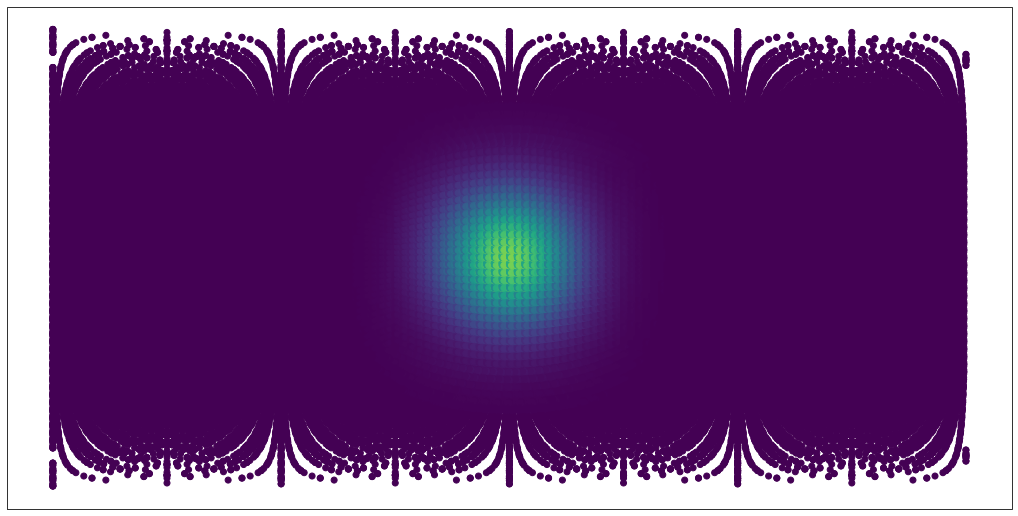

In [133]:
plt.figure(figsize=(18,10))
ax = plt.axes(projection=ccrs.PlateCarree())

sc = ax.scatter(lon_array.values.flatten(), lat_array.values.flatten(), 
                c = init.values.flatten(), cmap='viridis', transform=ccrs.PlateCarree())
# plt.colorbar(sc, ax=ax, label='Value')

In [123]:
np.max(init)

<xarray.DataArray ()>
array(1.17867375)

### Unit Test:

In [139]:
field_init = init_gaussian(lat_array, lon_array)

In [171]:
v_vector = xr.concat([u_comp * field_init, v_comp * field_init], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))

unit_RHS = (stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D) * W_ij) - weak_div(u_comp * field_init, v_comp * field_init, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij)

In [172]:
unit_RHS

<xarray.DataArray (n_face: 5400, x2: 4, y2: 4)>
array([[[-1.95747769e-10,  8.40993718e-10,  7.41460048e-10,
          4.43704930e-10],
        [-1.97152428e-09, -1.03397577e-25, -3.61891518e-25,
          1.60808843e-09],
        [-2.11652254e-09,  5.68686671e-25,  1.80945759e-25,
          1.74037857e-09],
        [-6.63788182e-10, -1.02843798e-09, -9.14084798e-10,
          1.95724458e-10]],

       [[-1.73197398e-10,  6.18956439e-10,  5.49363659e-10,
          3.55212620e-10],
        [-1.60808843e-09,  3.10192730e-25, -1.55096365e-25,
          1.33447969e-09],
        [-1.74037857e-09,  2.58493941e-25, -7.75481824e-26,
          1.45555002e-09],
        [-5.30123151e-10, -7.67213138e-10, -6.86274057e-10,
          1.79235502e-10]],

       [[-1.53847232e-10,  4.62761311e-10,  4.13138516e-10,
          2.89690327e-10],
...
        [ 9.91818139e-06, -1.04868762e-04, -1.01505189e-04,
         -4.46203501e-05]],

       [[ 6.70677868e-05,  1.33780654e-04,  1.28277900e-04,
         -5.69939408e-06],
        [ 1.74657204e-04, -5.42101086e-20, -2.71050543e-20,
         -1.34730608e-04],
        [ 1.41477939e-04, -7.45388994e-20, -2.03287907e-20,
         -1.09009814e-04],
        [ 4.36935229e-06, -9.96006208e-05, -9.53930856e-05,
         -3.76065410e-05]],

       [[ 5.64173046e-05,  1.25079090e-04,  1.18598288e-04,
          1.69406589e-21],
        [ 1.34730608e-04, -5.75982404e-20,  0.00000000e+00,
         -1.00635842e-04],
        [ 1.09009814e-04,  5.42101086e-20, -1.35525272e-20,
         -8.13676004e-05],
        [ 1.69406589e-21, -9.24994722e-05, -8.76458740e-05,
         -3.11468514e-05]]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

In [175]:
line_int_weights = np.ones((npts, npts))
line_int_weights[0, :] = quad_weights(GLL_points)
line_int_weights[-1, :] = quad_weights(GLL_points)

In [177]:
np.rot90(line_int_weights, k=1)

array([[0.16666667, 1.        , 1.        , 0.16666667],
       [0.83333333, 1.        , 1.        , 0.83333333],
       [0.83333333, 1.        , 1.        , 0.83333333],
       [0.16666667, 1.        , 1.        , 0.16666667]])

In [178]:
flux_array = transport_analytic_flux(u_comp, v_comp, field_init).drop_vars(['x2', 'y2'])
tb_array_flux_n = return_normal((flux_array * tb_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv, 1) * line_int_weights
lr_array_flux_n = return_normal((flux_array * lr_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv, 0) * np.rot90(line_int_weights, k=1)

lr_array_flux_n + tb_array_flux_n

<xarray.DataArray (n_face: 5400, x2: 4, y2: 4)>
array([[[-1.95747769e-10,  8.40993718e-10,  7.41460048e-10,
         -4.43704930e-10],
        [ 1.97152428e-09,  0.00000000e+00,  0.00000000e+00,
          1.60808843e-09],
        [ 2.11652254e-09,  0.00000000e+00,  0.00000000e+00,
          1.74037857e-09],
        [ 6.63788182e-10,  1.02843798e-09,  9.14084798e-10,
          1.95724458e-10]],

       [[-1.73197398e-10,  6.18956439e-10,  5.49363659e-10,
         -3.55212620e-10],
        [ 1.60808843e-09,  0.00000000e+00,  0.00000000e+00,
          1.33447969e-09],
        [ 1.74037857e-09,  0.00000000e+00,  0.00000000e+00,
          1.45555002e-09],
        [ 5.30123151e-10,  7.67213138e-10,  6.86274057e-10,
          1.79235502e-10]],

       [[-1.53847232e-10,  4.62761311e-10,  4.13138516e-10,
         -2.89690327e-10],
...
        [-9.91818139e-06,  1.04868762e-04,  1.01505189e-04,
         -4.46203501e-05]],

       [[ 6.70677868e-05,  1.33780654e-04,  1.28277900e-04,
          5.69939408e-06],
        [-1.74657204e-04,  0.00000000e+00,  0.00000000e+00,
         -1.34730608e-04],
        [-1.41477939e-04,  0.00000000e+00,  0.00000000e+00,
         -1.09009814e-04],
        [-4.36935229e-06,  9.96006208e-05,  9.53930856e-05,
         -3.76065410e-05]],

       [[ 5.64173046e-05,  1.25079090e-04,  1.18598288e-04,
          0.00000000e+00],
        [-1.34730608e-04,  0.00000000e+00,  0.00000000e+00,
         -1.00635842e-04],
        [-1.09009814e-04,  0.00000000e+00,  0.00000000e+00,
         -8.13676004e-05],
        [ 6.77626358e-21,  9.24994722e-05,  8.76458740e-05,
         -3.11468514e-05]]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15